In [217]:
import numpy as np
import pymc as pm
#import pytensor.tensor as at
import pandas as pd
#import pickle
#import xarray as xr
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 20})
FormatStrFormatter = plt.matplotlib.ticker.FormatStrFormatter

import covid19_inference.covid19_inference as cov19
#import utils
import plot

Create dummy data for input.

In [237]:
# length of data 
data_length = 40

# make dummy data with only zeros
dummy_data_0 = np.zeros(data_length)

# make dummy data with a one in the beginng and zeros otherwise
dummy_data_1 = np.zeros(data_length)
dummy_data_1[10] = 1

# make dummy data with only ones
dummy_data_2 = np.ones(data_length)

# make linearly increasing dummy data
lin_data = np.linspace(0, 1, data_length)

# make stepwise dummy data
step_data = np.zeros(data_length)
step_data[0:10] = 1
step_data[10:20] = 2
step_data[20:30] = 0
step_data[30:40] = 1

input_data = dummy_data_1

Create model and calculate convolution.

In [255]:
# kernel parameters
mu = 2
sigma = 3

# convolution parameters
len_output_arr = 37
diff_input_output = data_length - len_output_arr

model = pm.Model()
with model:
    data = pm.ConstantData("data", input_data)

    output = cov19.model.delay_cases(
        cases=data,
        delay_kernel="gamma",
        median_delay=mu,
        scale_delay=sigma,
        len_input_arr=data_length,
        len_output_arr=len_output_arr,
        diff_input_output=diff_input_output,
    )
    output = output.eval()

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


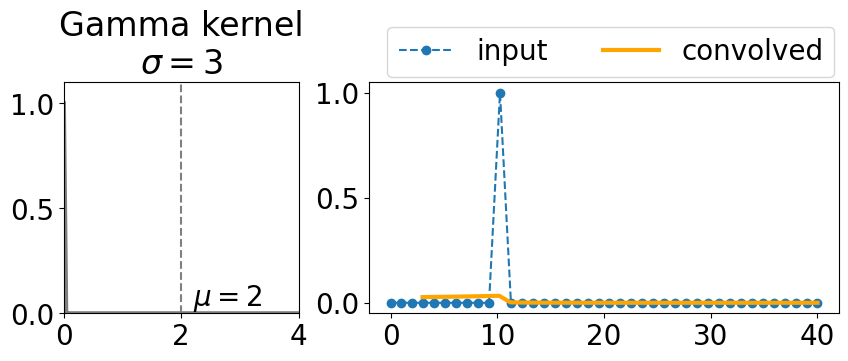

In [256]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3), width_ratios=[1,2])
lw = 3

# plot the gamma kernel
ax = axs[0]
xmax = 2* mu
x = np.linspace(0, xmax, 100)
y = cov19.model._utility.tt_gamma(
    x,
    mu=mu,
    sigma=sigma,
).eval()
ax.plot(x, y, linewidth=3, color='grey')
ax.vlines(mu, 0, 1.1*max(y), linestyle='--', color='grey')
ax.text(mu*1.1, 0, f'$\mu={mu}$', ha='left', va='bottom')
ax.set_xlim(0, xmax)
ax.set_ylim(0, 1.1*max(y))
ax.set_title(f'Gamma kernel\n$\sigma={sigma}$')

# plot the 'data'
ax = axs[1]
x = np.linspace(0, data_length, data_length)
# plot input data
ax.plot(x, input_data, marker='o', label='input', ls='--')
# plot the convolution
x = np.linspace(diff_input_output, diff_input_output+len_output_arr, len_output_arr)
ax.plot(x, output, label='convolved', color='orange', lw=lw)
# format y-ticklabels to not return scientific notation
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
#ax.set_title('Data')
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1.3))

# Archived

In [42]:
trace = pm.sample(model=model, draws=100, tune=100, cores=1, chains=2)
with model:
    pm.compute_log_likelihood(trace)

Only 100 samples in chain.
WARNING  [pymc] Only 100 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
INFO     [pymc] Sequential sampling (2 chains in 1 job)
NUTS: [mu, sigma]
INFO     [pymc] NUTS: [mu, sigma]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 1 seconds.
INFO     [pymc] Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 1 seconds.


In [34]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> constant_data

In [45]:
trace.posterior['convolution']

<xarray.DataArray 'convolution' (chain: 2, draw: 100, convolution_dim_0: 100)>
array([[[5.00000000e-01, 3.49511912e-80, 1.01010101e-02, ...,
         9.69696970e-01, 9.79797980e-01, 9.89898990e-01],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [4.23112639e-01, 6.07256860e-29, 1.01010099e-02, ...,
         9.69696969e-01, 9.79797980e-01, 9.89898990e-01],
        ...,
        [3.06481080e-06, 1.52665743e-96, 1.01008529e-02, ...,
         9.69696812e-01, 9.79797823e-01, 9.89898833e-01],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [4.99980500e-01, 3.93808373e-09, 1.01007227e-02, ...,
         9.69696678e-01, 9.79797689e-01, 9.89898699e-01]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [4.06563149e-01, 2.19095281e-21, 1.01006760e-02, ...,
         9.69696636e-01, 9.79797646e-01, 9.89898656e-01]]])
Coordinates:
  * chain              (chain) int64 0 1
  * draw               (draw) int64 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * convolution_dim_0  (convolution_dim_0) int64 0 1 2 3 4 5 ... 95 96 97 98 99

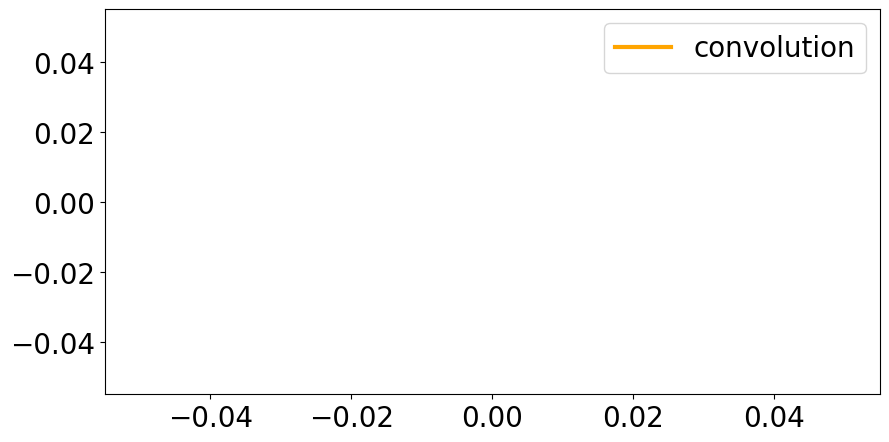

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 100, 100)
color = 'orange'
lw = 3

# plot input data
#ax.plot(x, trace.constant_data['data'], marker='o', color=color, label='input', ls='--')
# plot the convolution
plot.plot_timeseries(ax, x, trace.posterior['convolution'], 'convolution', color)

ax.legend()

Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

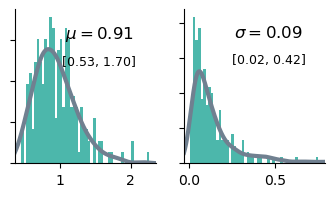

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(4, 2))
axs = axs.flatten()

cov19.plot.distribution(
    model, trace, "mu", dist_math="\mu", ax=axs[0]
)
cov19.plot.distribution(
    model, trace, "sigma", dist_math="\sigma", ax=axs[1]
)

In [ ]:
def create_model(
    model_in,
    base_mobility_data_in,
    observed_mobility_data_in,
    NPI_data_in,
    kurzarbeit_data_in,
    indicators_in,
    disease_data_in,
    delta_prcp_in=None,
):
    len_data = observed_mobility_data_in.shape[0]
    with model_in:
        # define data
        m_base_data = pm.ConstantData("m_base", base_mobility_data_in)
        NPI_data = pm.ConstantData("NPI_data", NPI_data_in)
        kurzarbeit_data = pm.ConstantData("kurzarbeit_data", kurzarbeit_data_in)
        # delta_weather = pm.ConstantData("delta_weather", del_weather_data_in)
        # avg_weather = pm.ConstantData("avg_weather", avg_weather_data_in)

        # meta-parameters for the convolution function (delay_cases)
        model_in.diff_data_sim = (
            0  # we are only interested in the reported cases, so no delay
        )
        model_in.sim_len = len_data - model_in.diff_data_sim

        # kurzarbeit
        delta_o = pm.LogNormal("delta_o", mu=np.log(5), tau=10)
        m = pm.Deterministic("o_*", m_base_data - delta_o * kurzarbeit_data)

        # impact of disease spread
        mu_z_prior = 0.9 ** len(indicators_in)
        for indicator in indicators_in:
            disease_data = pm.ConstantData(indicator, disease_data_in[indicator])

            ## define priors
            factor_disease = pm.LogNormal(
                f"z_{indicator}", mu=np.log(mu_z_prior), tau=10
            )
            mu_disease = pm.LogNormal(f"mu_{indicator}", mu=np.log(0.9), tau=10)
            delta = pm.LogNormal(f"delta_{indicator}", mu=np.log(0.1), tau=1)
            sigma_disease = pm.Deterministic(f"sigma_{indicator}", mu_disease - delta)
            ## convolution: SOMETHING IS AMISS HERE
            risk = cov19.model.delay_cases(
                cases=disease_data,
                delay_kernel="gamma",
                median_delay=mu_disease,
                scale_delay=sigma_disease,
                len_input_arr=len_data,
                len_output_arr=model_in.sim_len,
            )
            ## put it together
            exponent = -factor_disease * disease_data  # risk
            d = pm.Deterministic(f"d_{indicator}", at.exp(exponent))
            m = m * d

        # impact of NPI
        ## define priors
        factor_NPI = pm.LogNormal("z_S", mu=np.log(0.9), tau=10)
        ## put it together
        exponent = -factor_NPI * NPI_data
        s = pm.Deterministic("s", at.exp(exponent))
        m = m * s

        # impact of pandemic fatigue
        # p = pandemic_fatigue_factor_linear(len_data)
        # p = pandemic_fatigue_factor_sigmoid(len_data)
        # m = m * p

        # define likelihood
        m = pm.Deterministic("m", m)
        model_error = pm.HalfCauchy("sigma_model", beta=0.5)
        likelihood = pm.Normal(
            "likelihood", mu=m, sigma=model_error, observed=observed_mobility_data_in
        )


In [ ]:
indicators = ["C"]
name = "kurzarbeit"

disease_data = {}

# for saving the results
tags = ""
for indicator in indicators:
    tags += indicator + "_"
tag = tags + name

# # We create a directory for the results.
# dir_name = "results/" + tag
# ## We create the target directory if it does not exist yet
# if not os.path.exists(dir_name):
#     os.mkdir(dir_name)
#     print("Directory ", dir_name, " created.")
# else:
#     print("Directory ", dir_name, " already exists.")

# # To know for every result how it was produced, we copy this source code into the results directory.
# shutil.copyfile("model.py", f"{dir_name}/code_for_{tag}.py")
# shutil.copyfile("utils.py", f"{dir_name}/utils_for_{tag}.py")

# Data
## Out of home duration
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week

### get dates
mobility_dates = mobility_df.index.values
dates_2020 = mobility_dates[mobility_dates < np.datetime64("2020-12-20")]
mobility_dates_2020 = dates_2020[dates_2020 > np.datetime64("2020-03-29")]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64("2022-12-20")]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020) :]

### get out of home duration data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()

baseline_mobility_df = pd.read_csv(
    "data/mobility/baseline_mobility.csv", parse_dates=True, index_col=0
)
baseline_mobility_df = baseline_mobility_df.filter(
    items=mobility_dates_2022_shortened, axis=0
)
## replace index by mobility_dates_2020
baseline_mobility_df.index = mobility_dates_2020
## rename index to "date"
baseline_mobility_df.index.name = "date"
baseline_mobility = baseline_mobility_df["outOfHomeDuration"].to_xarray()


## Kurzarbeit
df = pd.read_csv("data/kurzarbeit.csv", sep=";")
df["year"] = df["Berichtsmonat"].str[-4:]
df["month"] = df["Berichtsmonat"].str[:-5]

### turn month names into numbers with german_month_to_num function
df["month"] = df["month"].apply(utils.german_month_to_num)

df_kurzarbeit_2020 = utils.get_weekly_kurzarbeit(df, mobility_dates_2020, "2020")
df_kurzarbeit_2022 = utils.get_weekly_kurzarbeit(
    df, mobility_dates_2022_shortened, "2022"
)

### get difference between 2020 and 2022 as fraction of population
population = 83237124
KA_2020 = df_kurzarbeit_2020["Anzahl Kurzarbeitende"].values
KA_2022 = df_kurzarbeit_2022["Anzahl Kurzarbeitende"].values
KA_diff = (KA_2020 - KA_2022) / population

### make xarray of KA_diff with mobility_dates_2020 as index
KA_diff_xr = xr.DataArray(KA_diff, coords=[mobility_dates_2020], dims=["date"])


## R
if "R" in indicators:
    path_R = "data/R/Germany/R_eff_Germany.csv"
    R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

    ### weekly average placed on Sunday
    df = utils.weekly_formatting(R_df, mobility_dates_2020)
    df = utils.transform_data(df["R_eff median"])
    R_data = df.to_xarray()
    disease_data["R"] = R_data

## OWID
if "ICU" in indicators or "C" in indicators or "H" in indicators:
    cov19.data_retrieval.set_data_dir("/data.nst/eiftekhar/covid19/")
    owid = cov19.data_retrieval.OWD()
    owid.download_all_available_data()

### cases
if "C" in indicators:
    case_data = owid._filter(
        value="new_cases_smoothed_per_million",
        country="Germany",
    )
    case_data = utils.weekly_formatting(case_data, mobility_dates_2020)
    case_data = utils.transform_data(case_data).to_xarray()
    disease_data["C"] = case_data

### ICU
if "ICU" in indicators:
    ICU_data = owid._filter(
        value="icu_patients_per_million",
        country="Germany",
    )
    ICU_data = utils.weekly_formatting(ICU_data, mobility_dates_2020)
    ICU_data = utils.transform_data(ICU_data).to_xarray()
    disease_data["ICU"] = ICU_data

### hospitalisations
if "H" in indicators:
    H_data = owid._filter(
        value="weekly_hosp_admissions_per_million",
        country="Germany",
    )
    H_data = utils.weekly_formatting(H_data, mobility_dates_2020)
    H_data = utils.transform_data(H_data).to_xarray()
    disease_data["H"] = H_data

## NPI
stay_at_home_2020 = utils.get_NPI_data(
    "data/NPIs/stay-at-home-covid.csv", mobility_dates_2020
)
stay_at_home_2020 = utils.transform_data(stay_at_home_2020)
stay_at_home_2020 = stay_at_home_2020["stay_home_requirements"].to_xarray()

## Weather
weather_df = pd.read_csv(
    "data/weather/weatherData2020and2022.csv", parse_dates=True, index_col=0
)

### filter for mobility_dates_2020
weather_df_2020 = weather_df[weather_df.index.isin(mobility_dates_2020)]
weather_df_2022 = weather_df[weather_df.index.isin(mobility_dates_2022_shortened)]

### calculate differences between the years
#### temperature
# delta_tmax = utils.return_differences(weather_df_2020, weather_df_2022, "tmax")
# delta_tmax = xr.DataArray(
#     delta_tmax, dims="date", coords={"date": mobility_dates_2020}, name="delta_tmax"
# )
#### precipitation
delta_prcp = utils.return_differences(weather_df_2020, weather_df_2022, "prcp")
delta_prcp = xr.DataArray(
    delta_prcp, dims="date", coords={"date": mobility_dates_2020}, name="delta_prcp"
)

### calculate average between the years
#### temperature
# average_tmax = utils.return_averages(weather_df_2020, weather_df_2022, "tmax")
# average_tmax = xr.DataArray(
#     average_tmax, dims="date", coords={"date": mobility_dates_2020}, name="average_tmax"
# )

# Model
inference_model = pm.Model()
create_model(
    inference_model,
    baseline_mobility,
    mobility_data_2020,
    stay_at_home_2020,
    KA_diff_xr,
    indicators,
    disease_data,
)

# Inference
trace = pm.sample(model=inference_model, draws=200, tune=200, cores=1, chains=2)
with inference_model:
    pm.compute_log_likelihood(trace)

# Save the trace
path = f"{dir_name}/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(trace, inference_file)
